In [107]:
!pip install ucimlrepo

LOADING THE DATASET

In [108]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())
print(df.shape)

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  
(45211, 17)


DATA PREPROCESSING

In [109]:
print(df.isnull().sum())

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [110]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["y"] = encoder.fit_transform(df["y"])

print(df["y"].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [111]:
X = df.drop("y", axis=1)
y = df["y"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(45211, 38)


TRAINING,TESTING AND SPILTTING THE DATASET

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(36168, 38)
(9043, 38)


MODEL TRAIN: DECISION TREE

In [113]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


MODEL TRAIN: RANDOM FOREST

In [114]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


ACCURACY EVALUATION: DECISION TREE

In [115]:
from sklearn.metrics import accuracy_score

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

ACCURACY EVALUATION: RANDOM FOREST

In [116]:
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

In [117]:
print(f"Decision Tree Accuracy : {dt_accuracy:.4f}")
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Decision Tree Accuracy : 0.8666
Random Forest Accuracy : 0.9046


CLASSIFICATION REPORT

In [118]:
from sklearn.metrics import classification_report

print("Decision Tree")
print(classification_report(y_test, dt_predictions))

print("\nRandom Forest")
print(classification_report(y_test, rf_predictions))

Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7985
           1       0.43      0.46      0.45      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.69      0.68      9043
weighted avg       0.87      0.87      0.87      9043


Random Forest
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



CONFUSION MATRIX: DECISION TREE

In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

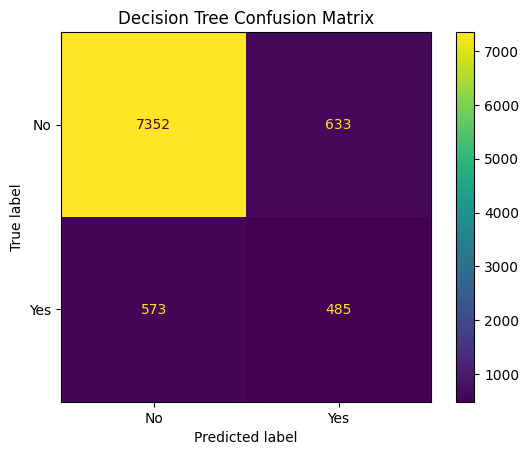

In [120]:
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    display_labels=["No", "Yes"]
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

CONFUSION MATRIX: RANDOM FOREST

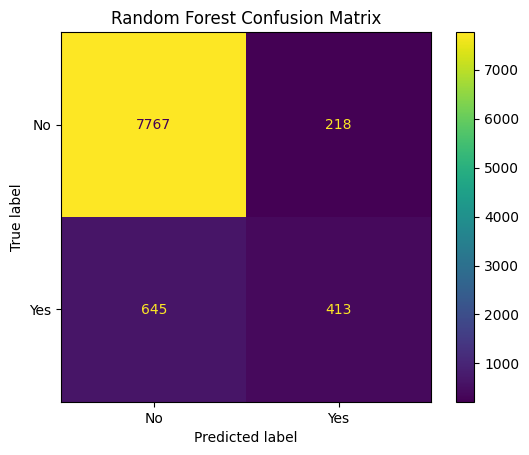

In [121]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

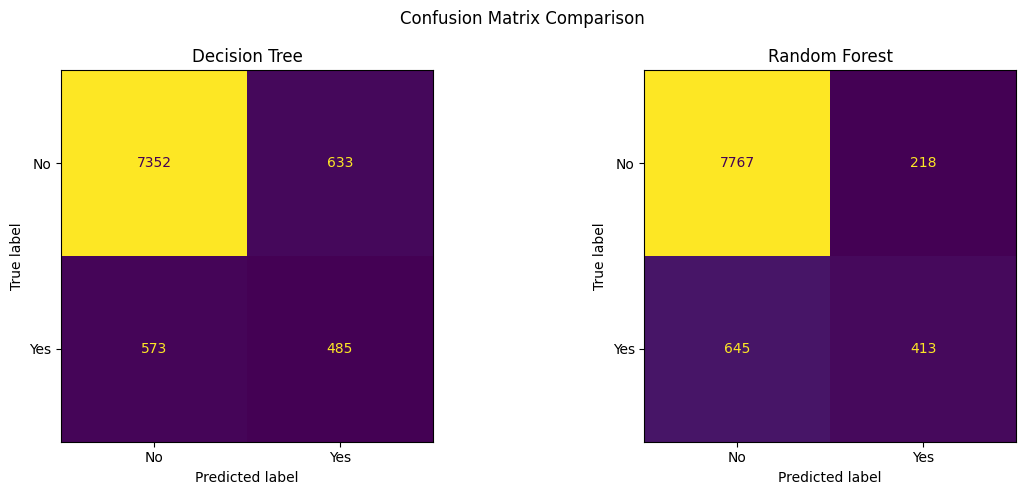

In [122]:
dt_cm = confusion_matrix(y_test, dt_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["No", "Yes"]
).plot(ax=axes[0], colorbar=False)

axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No", "Yes"]
).plot(ax=axes[1], colorbar=False)

axes[1].set_title("Random Forest")

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()

ROC CURVE: DECISION TREE

In [123]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

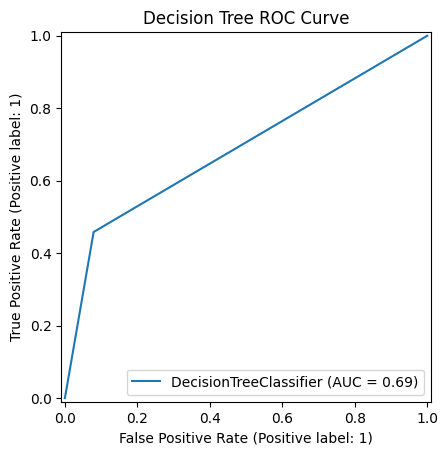

In [124]:
RocCurveDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.title("Decision Tree ROC Curve")
plt.show()

ROC CURVE: RANDOM FOREST

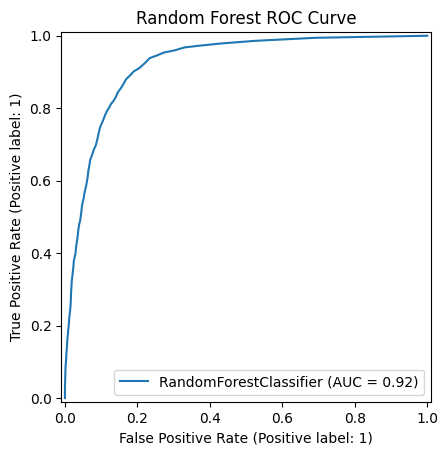

In [125]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")
plt.show()

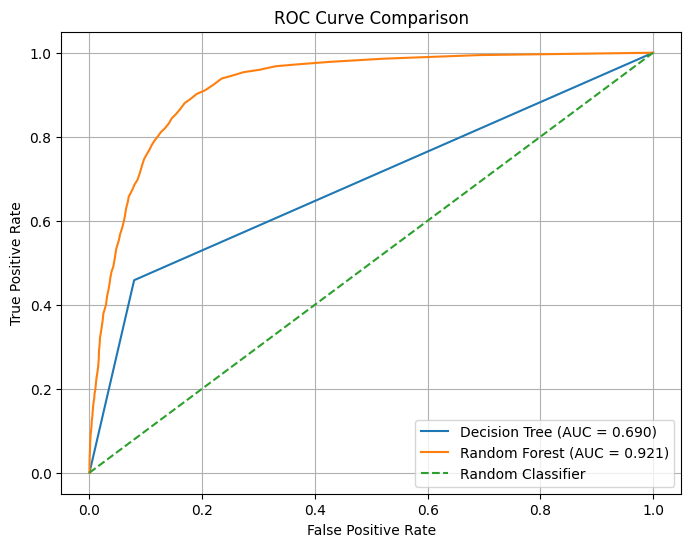

In [126]:
dt_probs = dt_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

BEST MODEL

In [127]:
if rf_accuracy > dt_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_model_accuracy = rf_accuracy
else:
    best_model = dt_model
    best_model_name = "Decision Tree"
    best_model_accuracy = dt_accuracy

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.4f}")

Best Model: Random Forest
Accuracy: 0.9046


In [128]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


Top 10 Important Features:
                Feature  Importance
3              duration    0.278377
1               balance    0.105954
0                   age    0.100430
2           day_of_week    0.090993
37     poutcome_success    0.061377
5                 pdays    0.043763
4              campaign    0.039742
6              previous    0.024312
22          housing_yes    0.020041
19  education_secondary    0.013524


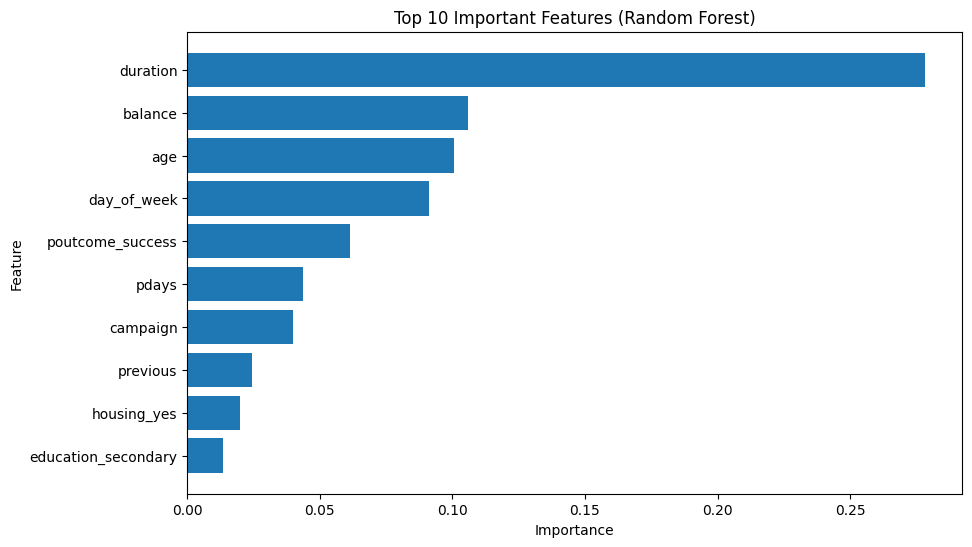

In [129]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 10 Important Features ({best_model_name})")

plt.gca().invert_yaxis()
plt.show()